# Library Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# Data loading

In [2]:
df = pd.read_csv('dataset/Earthquake.csv')

# Data cleaning

In [3]:
df = df.dropna(subset=['mag', 'latitude', 'longitude'])

# Feature Engineering

In [4]:
def assign_mag_class(m):
    if m < 3.0: return "Minor"
    elif m <= 5.0: return "Moderate"
    else: return "Strong"

df['mag_class'] = df['mag'].apply(assign_mag_class)

# Split train and test data

In [5]:
X = df[['mag', 'latitude', 'longitude']]
y = df['mag_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training

In [6]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Evaluation

==================== Decision Tree Performance ====================
Accuracy:  1.0000
Precision: 1.0000 (Weighted)
Recall:    1.0000 (Weighted)
F1-Score:  1.0000 (Weighted)

Per-Class Classification Report:
              precision    recall  f1-score   support

    Moderate       1.00      1.00      1.00      3048
      Strong       1.00      1.00      1.00       372

    accuracy                           1.00      3420
   macro avg       1.00      1.00      1.00      3420
weighted avg       1.00      1.00      1.00      3420



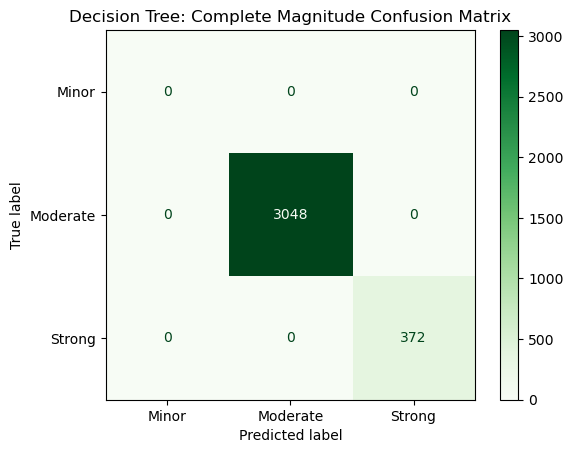

In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("==================== Decision Tree Performance ====================")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (Weighted)")
print(f"Recall:    {recall:.4f} (Weighted)")
print(f"F1-Score:  {f1:.4f} (Weighted)\n")

print("Per-Class Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# DEFINE ALL EXPECTED CLASSES EXPLICITLY
all_expected_classes = ["Minor", "Moderate", "Strong"]

# Pass the explicit list to force the matrix structure to include 'Minor'
cm = confusion_matrix(y_test, y_pred, labels=all_expected_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_expected_classes)

disp.plot(cmap='Greens')
plt.title("Decision Tree: Complete Magnitude Confusion Matrix")
plt.show()

# Prediction

In [8]:
new_event = pd.DataFrame([{
    'mag': 5.6,
    'latitude': 34.0522,
    'longitude': -118.2437
}])

prediction_label = model.predict(new_event)[0]
prediction_probabilities = model.predict_proba(new_event)[0]

print("--- Decision Tree Inference Test ---")
print(f"Raw Input Magnitude: 5.6")
print(f"Predicted Class Label: {prediction_label}")
print("Confidence Breakdown:")
for class_label, probability in zip(model.classes_, prediction_probabilities):
    print(f"  {class_label}: {probability:.2%}")

--- Decision Tree Inference Test ---
Raw Input Magnitude: 5.6
Predicted Class Label: Strong
Confidence Breakdown:
  Moderate: 0.00%
  Strong: 100.00%
